# 9. Classification
XX

<div style="border: 2px solid red; padding: 10px; color: red; font-weight: bold;">
 Note: This notebook has only been added on 03.12, still work in progress!
</div>


### Notebook Structure

**1.** XX
**2.** XX

## Import data & packages

In [1]:
# 1 - Import packages
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import seaborn as sns
import os
from qiime2 import Visualization
from biom import load_table

%matplotlib inline

In [2]:
# 2 - Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# 3 - Data directories
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
classification_dir = "../data/processed/classification"
# Create the new differential abundance analysis folder

In [4]:
%%bash -s "$classification_dir"
mkdir -p "$1"

### Set run and metric to work with

In [5]:
column_to_investigate = 'diet_milk'

## 1. Classification Pipeline

In [6]:
# ! qiime sample-classifier classify-samples --help

In [7]:
! mkdir -p "$classification_dir/results-$column_to_investigate"

! qiime taxa filter-table \
  --i-table $denoised_data_dir/dada2_table.qza \
  --i-taxonomy $taxonomy_data_dir/taxonomy.qza \
  --p-include "g__" \
  --p-exclude "g__;" \
  --o-filtered-table $classification_dir/results-$column_to_investigate/genus_only_table.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/classification/results-diet_milk/genus_only_table.qza


In [8]:
! qiime taxa collapse \
  --i-table $classification_dir/results-$column_to_investigate/genus_only_table.qza \
  --i-taxonomy $taxonomy_data_dir/taxonomy.qza \
  --p-level 6 \
  --o-collapsed-table $classification_dir/results-$column_to_investigate/collapsed_table.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/classification/results-diet_milk/collapsed_table.qza


In [9]:
# ('RandomForestClassifier',
#     'ExtraTreesClassifier', 'GradientBoostingClassifier',
#     'AdaBoostClassifier[DecisionTree]', 'AdaBoostClassifier[ExtraTrees]',
#     'KNeighborsClassifier', 'LinearSVC', 'SVC')

Ran into some issues with missing values, tried filling with unknown but messes with classification so dropping na rows now

In [12]:
# m = pd.read_csv("../data/processed/metadata/metadata_merged.tsv", sep="\t")
# m["diet_milk"].value_counts(dropna=False)


diet_milk
mixed    164
NaN       87
fd        70
bd        36
Name: count, dtype: int64

In [14]:
# # Load metadata
# m = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# # Replace ALL NaN values in EVERY column
# m = m.fillna("unknown")

# # Save new metadata file
# m.to_csv(f"{meta_data_dir}/metadata_merged_filled.tsv", sep="\t", index=False)


In [23]:
# Load metadata
m = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Drop rows where the prediction column has missing values
m = m.dropna(subset=[column_to_investigate])

# Save cleaned metadata
m.to_csv(f"{meta_data_dir}/metadata_merged_dropped.tsv", sep="\t", index=False)

In [26]:
! qiime feature-table filter-samples \
  --i-table $classification_dir/results-$column_to_investigate/collapsed_table.qza \
  --m-metadata-file $meta_data_dir/metadata_merged_dropped.tsv \
  --o-filtered-table $classification_dir/results-$column_to_investigate/collapsed_table_filtered.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/classification/results-diet_milk/collapsed_table_filtered.qza


In [27]:
cmd = f"""
if [ -d {classification_dir}/small-RF-classifier-{column_to_investigate} ]; then
    rm -r {classification_dir}/small-RF-classifier-{column_to_investigate}
fi

qiime sample-classifier classify-samples \
  --i-table {classification_dir}/results-{column_to_investigate}/collapsed_table_filtered.qza \
  --m-metadata-file {meta_data_dir}/metadata_merged_dropped.tsv \
  --m-metadata-column {column_to_investigate} \
  --p-test-size 0.2 \
  --p-estimator RandomForestClassifier \
  --p-random-state 15 \
  --p-n-jobs 3 \
  --output-dir {classification_dir}/small-RF-classifier-{column_to_investigate}
"""

print(cmd)
!bash -c "{cmd}"


if [ -d ../data/processed/classification/small-RF-classifier-diet_milk ]; then
    rm -r ../data/processed/classification/small-RF-classifier-diet_milk
fi

qiime sample-classifier classify-samples   --i-table ../data/processed/classification/results-diet_milk/collapsed_table_filtered.qza   --m-metadata-file ../data/processed/metadata/metadata_merged_dropped.tsv   --m-metadata-column diet_milk   --p-test-size 0.2   --p-estimator RandomForestClassifier   --p-random-state 15   --p-n-jobs 3   --output-dir ../data/processed/classification/small-RF-classifier-diet_milk

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved SampleEstimator[Classifier] to: ../data/processed/classification/small-RF-classifier-diet_milk

In [28]:
Visualization.load(f"{classification_dir}/small-RF-classifier-{column_to_investigate}/accuracy_results.qzv")

<visualization: Visualization uuid: d7d96b39-ef3d-442e-aca1-ac04098214a6>

In [39]:
cmd = f"""
qiime metadata tabulate \
  --m-input-file {classification_dir}/small-RF-classifier-{column_to_investigate}/test_targets.qza \
  --m-input-file {classification_dir}/small-RF-classifier-{column_to_investigate}/predictions.qza \
  --m-input-file {classification_dir}/small-RF-classifier-{column_to_investigate}/probabilities.qza \
  --o-visualization {classification_dir}/small-RF-classifier-{column_to_investigate}/test_predprob.qzv
"""

print(cmd)
!bash -c "{cmd}"


qiime metadata tabulate   --m-input-file ../data/processed/classification/small-RF-classifier-diet_milk/test_targets.qza   --m-input-file ../data/processed/classification/small-RF-classifier-diet_milk/predictions.qza   --m-input-file ../data/processed/classification/small-RF-classifier-diet_milk/probabilities.qza   --o-visualization ../data/processed/classification/small-RF-classifier-diet_milk/test_predprob.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/conda/lib/python3.10/site-packages/q2_sample_classifier/_transformer.py:76: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  lambda x: 

In [42]:
Visualization.load(f"{classification_dir}/small-RF-classifier-{column_to_investigate}/test_predprob.qzv")

<visualization: Visualization uuid: bd9767db-5401-4fc4-86e7-db2934f2137c>

In [30]:
! qiime metadata tabulate \
  --m-input-file "$classification_dir/small-RF-classifier-$column_to_investigate/feature_importance.qza" \
  --o-visualization "$classification_dir/small-RF-classifier-$column_to_investigate/feature_importance.qzv"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/classification/small-RF-classifier-diet_milk/feature_importance.qzv


In [31]:
Visualization.load(f"{classification_dir}/small-RF-classifier-{column_to_investigate}/feature_importance.qzv")

<visualization: Visualization uuid: ec040ad4-877c-45a5-8919-ea890c784242>

In [38]:
Visualization.load(f"{classification_dir}/small-RF-classifier-{column_to_investigate}/heatmap.qzv")

<visualization: Visualization uuid: 47683a81-dab0-436f-8696-4d7bdaef6f05>

In [40]:
! qiime sample-classifier heatmap \
  --i-table "$classification_dir/results-$column_to_investigate/collapsed_table_filtered.qza" \
  --i-importance "$classification_dir/small-RF-classifier-$column_to_investigate/feature_importance.qza" \
  --m-sample-metadata-file "$meta_data_dir/metadata_merged_dropped.tsv" \
  --m-sample-metadata-column "$column_to_investigate" \
  --p-group-samples \
  --p-feature-count 30 \
  --o-filtered-table "$classification_dir/small-RF-classifier-$column_to_investigate/important-feature-table-top-30.qza" \
  --o-heatmap "$classification_dir/small-RF-classifier-$column_to_investigate/important-feature-heatmap.qzv"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/classification/small-RF-classifier-diet_milk/important-feature-heatmap.qzv
Saved FeatureTable[Frequency] to: ../data/processed/classification/small-RF-classifier-diet_milk/important-feature-table-top-30.qza


In [41]:
Visualization.load(f"{classification_dir}/small-RF-classifier-{column_to_investigate}/important-feature-heatmap.qzv")

<visualization: Visualization uuid: 4484cb1d-45c4-44e6-8d97-4dbd1f01f432>

In [43]:
! mkdir -p "$classification_dir/results-$column_to_investigate/exported"

! qiime tools export \
  --input-path $classification_dir/small-RF-classifier-$column_to_investigate/important-feature-table-top-30.qza \
  --output-path $classification_dir/results-$column_to_investigate/exported

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/classification/small-RF-classifier-diet_milk/important-feature-table-top-30.qza as BIOMV210DirFmt to directory ../data/processed/classification/results-diet_milk/exported


In [44]:
biom_path = f"{classification_dir}/results-{column_to_investigate}/exported/feature-table.biom"

# Load BIOM
table = load_table(biom_path)
df = table.to_dataframe(dense=True)

# Extract genus name and replace index
df.index = df.index.str.extract(r"g__([^;]+)$")[0]

df.head()

,bd,mixed,fd
0,,,
Faecalibacterium,340.0,182295.0,78469.0
Escherichia-Shigella,65124.0,689890.0,398578.0
Bacteroides,461087.0,1716049.0,433056.0
Anaerostipes,45.0,51336.0,22157.0
Pseudomonas,207.0,1690.0,1079.0


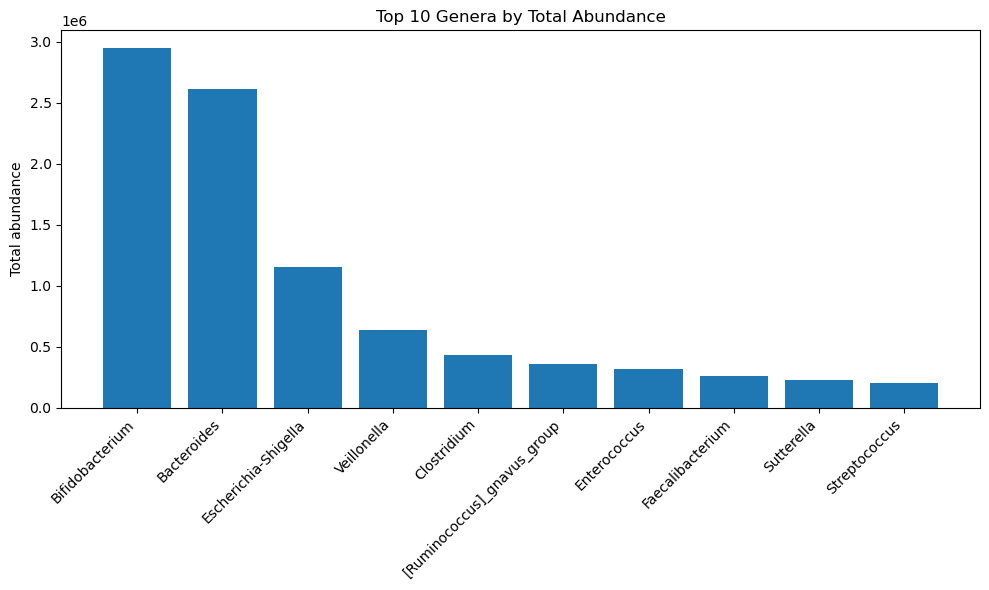

In [45]:
# Drop missing genera
df_clean = df.dropna()

# Compute total abundance per genus
genus_abundance = df_clean.sum(axis=1).sort_values(ascending=False)
top10 = genus_abundance.head(10)

plt.figure(figsize=(10,6))
plt.bar(top10.index, top10.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Total abundance")
plt.title("Top 10 Genera by Total Abundance")
plt.tight_layout()
plt.show()

## 2. Test for overfitting or underfitting

Another way of evaluating a trained supervised ML model (classifier or regressor) is by checking whether the model tends to overfit or underfit the data. 

Let's first define these two terms: 
* Underfitting: The model displays poor performance on the training as well as the test dataset. It essentially fails to learn from the data provided.  
* Overfitting: The model fits the training data very well (almost learns it by heart) but its performance on the test data is disproportionally bad. 

As we have seen above in the classification section 2.2, our initially trained classifier (in `$data_dir/small-RF-classifier/sample_estimator.qza`) performs very well on the test set. Hence, it generalises well on previously unseen data. If the test performance is that high, there is usually no need to worry about over- or underfitting as these are both indicated by low test performance. But assuming the above trained model performed very bad on the test set, we would want to find out whether this was due to over- or underfitting. In case of overfitting, we would need to restrict the model's learning, e.g. by regularisation or choosing a simpler model. In case of underfitting, we might need to choose a more complex model or create some sophisticated features (feature engineering). 

Now you might be interested in how you could find out whether your model over- or underfits in QIIME 2. Great thought :). To do this, you want to create predictions on the previously used train set, evaluate the model on these and compare this model performance to the model performance on the test set.

If you want see the model performance on the train set, run and inspect the commands provided below.


* Our first goal is to get a feature table that only contains features of the train set. For this we first want to filter the metadata file by the train targets that were used to train the classifier:
